<a href="https://colab.research.google.com/github/SS-Actinium/elevate_labs_task4/blob/main/Int_Elevate_Lab_4_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 4
1. Choose a binary classification dataset.
2. Train/test split and standardize features.
3. Fit a Logistic Regression model.
4. Evaluate with confusion matrix, precision, reca l, ROC-AUC.
5. Tune threshold and explain sigmoid function.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, roc_auc_score, roc_curve)

1. Choose a binary classification dataset.

In [14]:
# Load the Breast Cancer dataset
cancer_data = load_breast_cancer()
X = cancer_data.data
y = cancer_data.target

2. Train/test split and standardize features.

In [15]:
# Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dataset loaded. Shape: {X.shape}")
print("Data split into train/test and standardized.\n")

Dataset loaded. Shape: (569, 30)
Data split into train/test and standardized.



3. Fit a Logistic Regression model.

In [16]:
# Initialize and fit the model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)
print("Logistic Regression model successfully trained.\n")

Logistic Regression model successfully trained.



4. Evaluate with confusion matrix, precision, reca l, ROC-AUC.

Precision: 0.9861
Recall:    0.9861
ROC-AUC:   0.9954



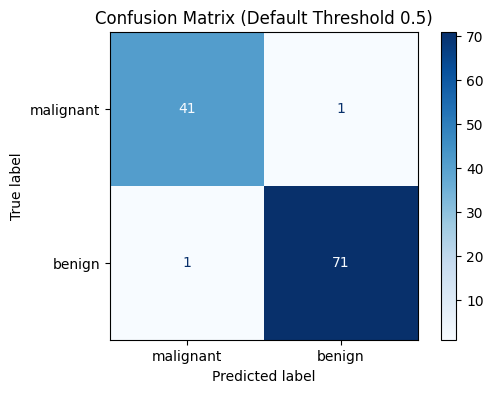

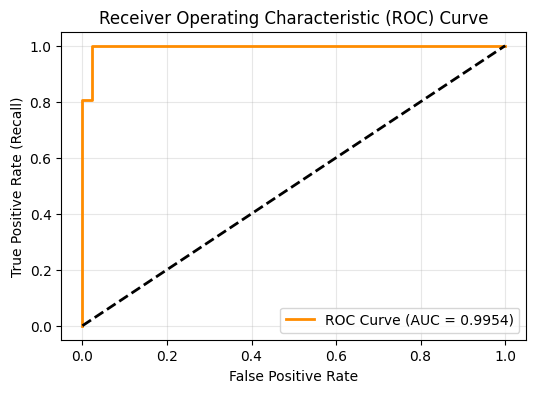

In [17]:
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}\n")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cancer_data.target_names)
fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix (Default Threshold 0.5)')
plt.show()

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=2) # Diagonal random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

5. Tune threshold and explain sigmoid function.

Threshold: 0.3 -> Precision: 0.9730 | Recall: 1.0000
Threshold: 0.5 -> Precision: 0.9861 | Recall: 0.9861
Threshold: 0.8 -> Precision: 0.9851 | Recall: 0.9167


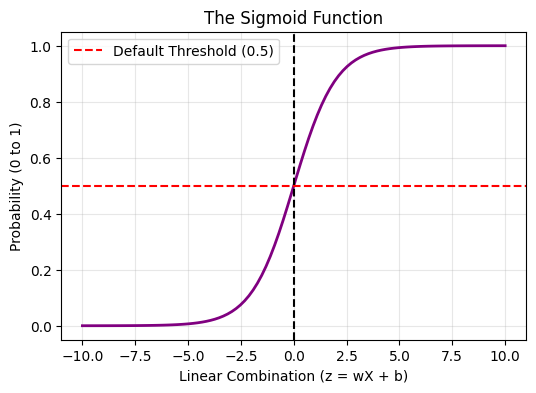

In [18]:
thresholds_to_test = [0.3, 0.5, 0.8]
for thresh in thresholds_to_test:
    # Custom predictions based on threshold
    y_pred_custom = (y_pred_proba >= thresh).astype(int)

    p = precision_score(y_test, y_pred_custom)
    r = recall_score(y_test, y_pred_custom)
    print(f"Threshold: {thresh:.1f} -> Precision: {p:.4f} | Recall: {r:.4f}")

# Plotting the Sigmoid Function for visualization
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_values = np.linspace(-10, 10, 100)
sigmoid_values = sigmoid(z_values)

plt.figure(figsize=(6, 4))
plt.plot(z_values, sigmoid_values, color='purple', lw=2)
plt.axvline(x=0, color='k', linestyle='--')
plt.axhline(y=0.5, color='r', linestyle='--', label='Default Threshold (0.5)')
plt.title('The Sigmoid Function')
plt.xlabel('Linear Combination (z = wX + b)')
plt.ylabel('Probability (0 to 1)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()